# Noise calibration (interactive)

This notebook launches the `kpms.noise_calibration` widget. Run the code cell below in a Jupyter environment with widgets enabled (e.g., JupyterLab).

Repo root: /Users/atanugiri/Downloads/kpms_analysis
Using project path: /Users/atanugiri/Downloads/dlc-pose-estimation/Black-ToyStick
Using workspace config: /Users/atanugiri/Downloads/kpms_analysis/configs/BlackToyStick.yml
Loading keypoints from: /Users/atanugiri/Downloads/dlc-pose-estimation/Black-ToyStick/raw_pose_data


Loading keypoints:   0%|                         | 0/34 [00:00<?, ?it/s]

Loading keypoints: 100%|███████████████| 34/34 [00:00<00:00, 191.79it/s]


Found 34 recordings with 608683 total frames
Bodyparts: ['Head', 'Neck', 'Midback', 'Lowerback', 'Tailbase']
Launching noise calibration widget...


Loading sample frames: 100%|██████████| 100/100 [00:02<00:00, 48.25it/s]


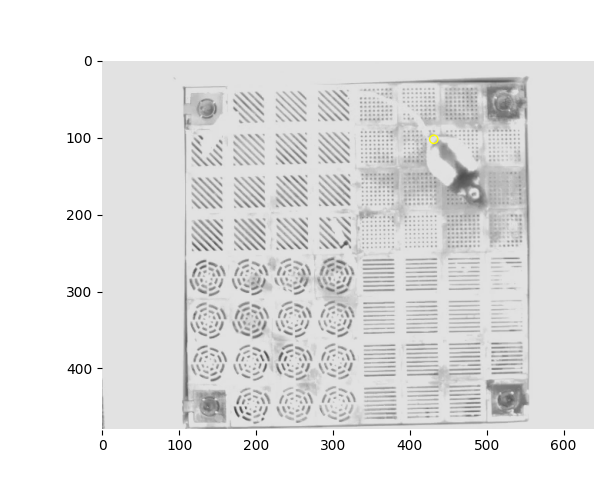

In [20]:
import os
import sys
from pathlib import Path
import numpy as np

# Add repo root to path so kpms_utils can be imported
_REPO_ROOT = Path.cwd()
if _REPO_ROOT.name != "kpms_analysis":
    for parent in _REPO_ROOT.parents:
        if parent.name == "kpms_analysis":
            _REPO_ROOT = parent
            break

if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

print(f"Repo root: {_REPO_ROOT}")

import keypoint_moseq as kpms
from kpms_utils.config_utils import load_yaml_config
from kpms_utils.path_utils import get_kpms_project_dir, get_pose_data_dir

# Hardcoded for simplicity
PROJECT_PATH = "/Users/atanugiri/Downloads/dlc-pose-estimation/Black-ToyStick"
WORKSPACE_CONFIG = str(_REPO_ROOT / "configs/BlackToyStick.yml")
USE_FILTERED = False

print(f"Using project path: {PROJECT_PATH}")
print(f"Using workspace config: {WORKSPACE_CONFIG}")

PROJECT_PATH = Path(PROJECT_PATH).resolve()

kpms_project_dir = get_kpms_project_dir(PROJECT_PATH)
pose_data_dir = get_pose_data_dir(PROJECT_PATH, use_filtered=USE_FILTERED)
video_dir = PROJECT_PATH / "videos"

# Load workspace config and keypoints
workspace_config = load_yaml_config(WORKSPACE_CONFIG)
fmt = workspace_config.get("pose_estimation_format", "deeplabcut")
ext = workspace_config.get("pose_file_extension") or None
recursive = workspace_config.get("recursive_search", True)
bodyparts = workspace_config.get("bodyparts")
use_bodyparts = workspace_config.get("use_bodyparts")

print(f"Loading keypoints from: {pose_data_dir}")
coordinates, confidences, bodyparts_loaded = kpms.load_keypoints(
    str(pose_data_dir),
    format=fmt,
    extension=ext,
    recursive=recursive,
)

# Print summary
if isinstance(coordinates, dict):
    total_frames = sum(v.shape[0] for v in coordinates.values())
    print(f"Found {len(coordinates)} recordings with {total_frames} total frames")
else:
    print(f"Loaded {coordinates.shape[0]} frames")

print(f"Bodyparts: {bodyparts_loaded}")

# Extract noise calibration parameters from config
error_estimator = workspace_config.get("error_estimator", {})
if not isinstance(error_estimator, dict):
    error_estimator = {}
conf_threshold = workspace_config.get("conf_threshold", 0.9)

# Launch the interactive widget
print(f"Launching noise calibration widget...")
kpms.noise_calibration(
    str(kpms_project_dir),
    coordinates,
    confidences,
    bodyparts=bodyparts or bodyparts_loaded,
    use_bodyparts=use_bodyparts,
    video_dir=str(video_dir),
    error_estimator=error_estimator,
    conf_threshold=conf_threshold,
    video_extension=workspace_config.get("video_extension"),
    conf_pseudocount=workspace_config.get("conf_pseudocount", 0.001),
)
